In [1]:
%config InlineBackend.figure_format = 'retina'

from astropy import constants as const
from astropy import units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import pandas as pd

from collections import namedtuple

from matplotlib.patches import Rectangle
from scipy.interpolate import CubicSpline

from iminuit.cost import LeastSquares
from iminuit import Minuit

from astropy.visualization import ZScaleInterval, LinearStretch, imshow_norm
from astropy.coordinates import EarthLocation, SkyCoord, GCRS, AltAz
from astropy.wcs.utils import pixel_to_skycoord
from astropy.nddata import Cutout2D
from astropy.table import QTable
from astropy.time import Time
from astropy.wcs import WCS
from astropy import modeling

from lsst.daf.butler import Butler
from lsst.afw import cameraGeom

INFO:numexpr.utils:Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
INFO:numexpr.utils:Note: NumExpr detected 128 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:numexpr.utils:NumExpr defaulting to 16 threads.


In [2]:
from datetime import timedelta

class WAASData:

    def __init__(self, filename):

        self.filename = filename

        waas = pd.read_csv(filename, sep=r'\s+', header=None,
                        names=['jd','t0','ura','x','y','z','vx','vy','vz','ax','ay','az','f0','f1'])

        waas = pd.concat([waas])

        jd_time = Time(waas.jd, format='jd')
        waas['date'] = pd.to_datetime(jd_time.utc.isot, utc=True)
        waas.set_index('date', inplace=True)

        self.waas = waas[['x','y','z']]


    def create_interpolated_waas(self, tai_time, resample_period='30.0s'):

        stop_time = tai_time + 15.0*u.min
        start_time = tai_time - 15.0*u.min
        df_timewindow = self.waas.loc[start_time.utc.iso:stop_time.utc.iso]
        
        df_resampled = df_timewindow.resample(resample_period).asfreq()
        combined = pd.concat([df_resampled, df_timewindow]).sort_index()
        combined = combined[~combined.index.duplicated(keep='first')] # Why is this only necessary now?!

        combined.interpolate(method='cubicspline', inplace=True)

        self.interpolated =  combined

    def calculate_waas_position(self, tai_time, shutter_offset = 0.0 * u.second, time_offset= 0 * u.second):
 
        # Add a delta time to the header plus shutter delay time if necessary.
        tai_time = tai_time + time_offset + shutter_offset

        find_time = pd.to_datetime(tai_time.utc.isot, utc=True)
        found_index = self.interpolated.index.get_indexer([find_time], method='nearest')[0]

        found_time = self.interpolated.index[found_index]
        found_x = self.interpolated.iloc[found_index].x * u.m
        found_y =  self.interpolated.iloc[found_index].y * u.m
        found_z =  self.interpolated.iloc[found_index].z * u.m
        
        ground = EarthLocation.of_site('Rubin Observatory', refresh_cache=True)
        satellite = EarthLocation.from_geocentric(found_x, found_y, found_z)

        # Calculate and remove the 1st order light travel time
        ground_itrs = ground.get_itrs()
        satellite_itrs = satellite.get_itrs()
        light_travel_time = (ground_itrs.data - satellite_itrs.data).norm()/const.c
                
        tai_time -= light_travel_time
    
        # Transform position to RA/DEC (with no dirunal aberration)
        found_altaz = satellite.get_itrs(obstime=tai_time, location=ground).transform_to(AltAz(obstime=tai_time, location=ground))
        altaz_coordinate = SkyCoord(alt = found_altaz.alt, az = found_altaz.az, obstime=tai_time, location=ground, frame='altaz')
        icrs = altaz_coordinate.transform_to('icrs')

        # Calculate aberration to subtract from measured values shifted by the WCS solution
        obsgeoloc, obsgeovel = ground.get_gcrs_posvel(tai_time)
        gcrs_geo = icrs.transform_to(GCRS(obstime=tai_time))
        gcrs_topo = icrs.transform_to(GCRS(obstime=tai_time, obsgeoloc=obsgeoloc, obsgeovel=obsgeovel))

        delta_ra = gcrs_topo.ra.deg - gcrs_geo.ra.deg
        delta_dec = gcrs_topo.dec.deg- gcrs_geo.dec.deg

        #return found_time, icrs.ra.deg - delta_ra, icrs.dec.deg - delta_dec
        return found_time, icrs.ra.deg, icrs.dec.deg


In [3]:
# Return an exposure

data_id = namedtuple('dataID', 'day_obs, seq_num')

def get_exposure(data_id, sat_pos):

    query = (f"instrument = 'LSSTCam' " 
         f'AND day_obs = {data_id.day_obs} ' 
         f'AND seq_num = {data_id.seq_num} '
         f'AND visit_detector_region.region OVERLAPS POINT({sat_pos.ra.deg}, {sat_pos.dec.deg})')

    dataset_refs = butler.query_datasets('preliminary_visit_image', where = query)
    pvi = butler.get(dataset_refs[0])

   # Only Return a PVI if the point is totally contained in one sensor.  
    if len(dataset_refs) == 1:
      return pvi
    else:
      print(data_id.day_obs, data_id.seq_num, 'Found ', len(dataset_refs), 'overlapping sensors.')
      return None
    

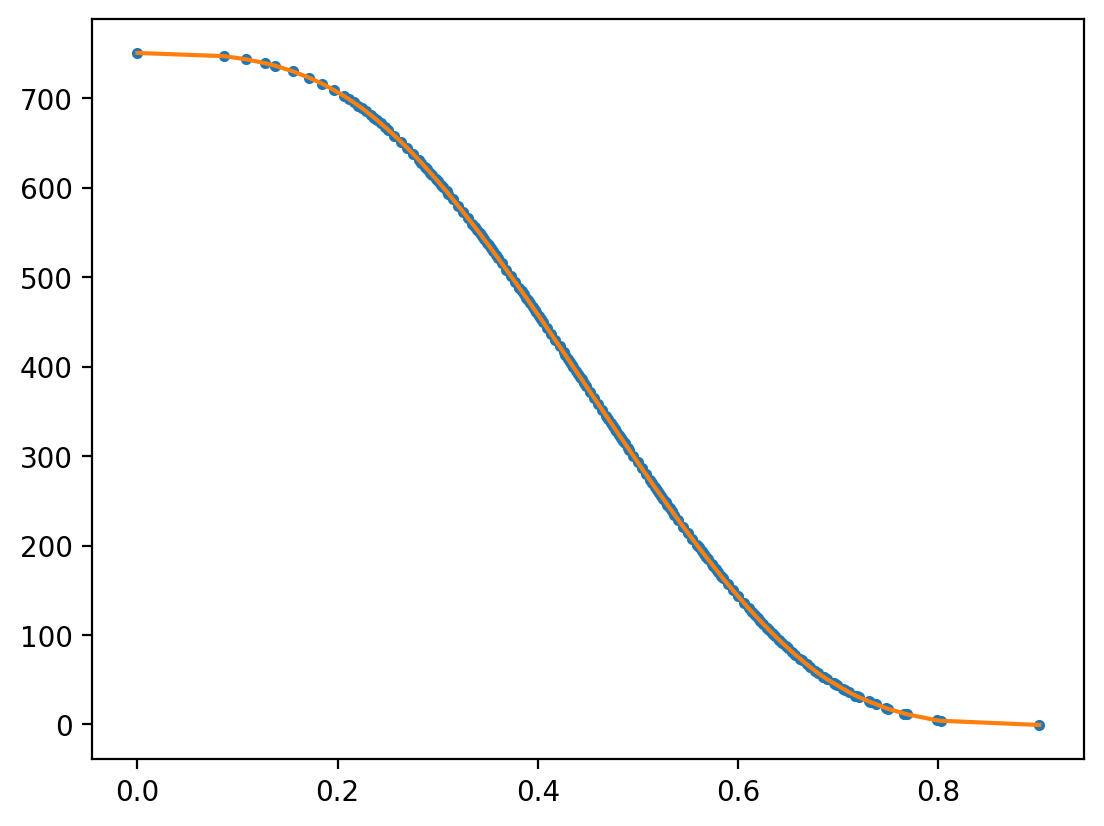

In [4]:
# Make a basic shutter motion profile 

hall = pd.read_csv('/sdf/home/c/cwalter/MC_O_20260105_000249.csv').query("series == 'OPEN'").sort_values('time_s')
shutter_spline = CubicSpline(hall.time_s, hall.position_mm)
spline_position = shutter_spline.__call__(hall.time_s)

plt.plot(hall.time_s, hall.position_mm, 'o', markersize=3.0)
plt.plot(hall.time_s, spline_position, '-')

In [5]:
# Setup the butler at USDF
CWW = 'u/cwalter/LSSTCam/timing_test'
butler = Butler('/repo/embargo', collections=CWW)

INFO:botocore.credentials:Found credentials in shared credentials file: /sdf/home/c/cwalter/.lsst/aws-credentials.ini


In [6]:
# Get the shutter open times for all of the exposures.
# Result is a dictionary keyed on sequence number

day_obs = 20260302

query = (f"instrument = 'LSSTCam' " 
         f'AND day_obs = {day_obs} ' 
         f'AND detector = 97 ' 
         f'AND seq_num IN (438..493)')

print('Searching for:', query)
header_data_ids = butler.query_datasets('preliminary_visit_image', where = query)

time_open_dict = {}
time_close_dict = {}
open_dict = {}

for ref in header_data_ids:
    header = butler.get("preliminary_visit_image.metadata", ref.dataId)

    seq_num = header['SEQNUM']
    start_tai_time = header['SHUTTER OPEN STARTTIME TAI ISOT']
    stop_tai_time = header['SHUTTER CLOSE STARTTIME TAI ISOT']
    open_side = header['SHUTTER OPEN SIDE']
    close_side = header['SHUTTER CLOSE SIDE']

    time_open_dict[seq_num] = start_tai_time
    time_close_dict[seq_num] = stop_tai_time
    open_dict[seq_num] =  open_side
 
print('Found', len(time_open_dict), 'shutter open times.')

Searching for: instrument = 'LSSTCam' AND day_obs = 20260302 AND detector = 97 AND seq_num IN (438..493)


INFO:aiobotocore.credentials:Found credentials in shared credentials file: /sdf/home/c/cwalter/.lsst/aws-credentials.ini
INFO:aiobotocore.credentials:Found credentials in shared credentials file: /sdf/home/c/cwalter/.lsst/aws-credentials.ini


Found 56 shutter open times.


In [7]:
# Make an (empty) QTable to hold the results
t = QTable()

t['seq_id'] = np.array([], dtype='i8')
t['tai_start_time'] = Time([], format='isot', scale='tai')
t['tai_stop_time'] = Time([], format='isot', scale='tai')
t['open_side'] = np.array([], dtype='S')
t['sat_pos'] = SkyCoord([], [], unit='deg', frame='icrs')
t['adj_pos'] = SkyCoord([], [], unit='deg', frame='icrs')
t['shutter_delay'] = np.array([], dtype='f8') * u.second

t['fp_x'] = np.array([], dtype='f8') * u.centimeter
t['fp_y'] = np.array([], dtype='f8') * u.centimeter

t['start_pos'] = SkyCoord([], [], unit='deg', frame='icrs')
t['stop_pos'] = SkyCoord([], [], unit='deg', frame='icrs')

t['pvi'] = np.array([], dtype='object')

# Set the column formats

def coord_format(x):
    return x.to_string(precision=3)

t['shutter_delay'].info.format = '4.3f'
t['sat_pos'].info.format = coord_format
t['adj_pos'].info.format = coord_format

t['fp_x'].info.format = '4.2f'
t['fp_y'].info.format = '4.2f'

t['start_pos'].info.format = coord_format
t['stop_pos'].info.format = coord_format

# Index the table on the sequence ID
t.add_index('seq_id')

In [8]:
# Find WAAS Ra/Dec
# 439- 493

# Load WAAS File
waas = WAASData('/sdf/home/c/cwalter/notebooks/geosynchronous-satellites/WAAS-files/waas_output_260303.csv')

day_obs = 20260302
for seq_id in range(439, 494):

    # Find interpolated time and sky position
    tai_start_time = Time(time_open_dict[seq_id], scale='tai') # Shutter Open Time
    tai_stop_time = Time(time_close_dict[seq_id], scale='tai') # Shutter Open Time
    waas.create_interpolated_waas(tai_start_time, '.01s')

    found_time, found_ra, found_dec = waas.calculate_waas_position(tai_start_time, shutter_offset= 0 * u.second)
    sat_pos = SkyCoord(found_ra, found_dec, unit='deg', frame='icrs')

    # Retrieve image, detector, and WCS
    exposure = data_id(day_obs, seq_id)
    pvi = get_exposure(exposure, sat_pos)

    # Check to make sure the point is completely contained
    if pvi == None:
        continue

    image = pvi.getImage().getArray()
    detector = pvi.getDetector()
    wcs = WCS(pvi.wcs.getFitsMetadata())

    # Calculate shutter delay
    pixel_to_focalplane_transform = detector.getTransform(cameraGeom.PIXELS, cameraGeom.FOCAL_PLANE)
    sat_pixels = wcs.world_to_pixel(sat_pos)
    focal_plane_x, focal_plane_y = pixel_to_focalplane_transform.getMapping().applyForward(sat_pixels)

    match open_dict[seq_id]:
        case 'MINUSX':
            shutter_delay = shutter_spline.solve(focal_plane_y + 750.8/2) * u.second
        case 'PLUSX':
            shutter_delay = shutter_spline.solve(750.8/2 - focal_plane_y) * u.second

    # Calculate adjusted sat_pos after shutter delays
    found_time, found_ra, found_dec = waas.calculate_waas_position(tai_start_time, shutter_offset = shutter_delay)
    adj_pos = SkyCoord(found_ra, found_dec, unit='deg', frame='icrs')

    # Make a cutout
    ra_box = (15.0*u.arcsec * 12, 15*u.arcsec) 
    ra_shift = 15*u.arcsec * 10 / 2.0 + shutter_delay * 15*u.arcsec / u.second
    shifted_pos = sat_pos.spherical_offsets_by(ra_shift, 0*u.arcsec)
    cut_out = Cutout2D(image, shifted_pos , ra_box, wcs=wcs, mode='partial')

    # Find the fitted points.
    # First check to make sure track is fully contained 
    if not np.isnan(cut_out.data).any():

        # Find start Dec points at beginning and end of track
        summed_dec_start = cut_out.data[:80].sum(axis=0)
        summed_dec_stop = cut_out.data[-100:].sum(axis=0)

        # Fit Gaussian
        fitter = modeling.fitting.LevMarLSQFitter()
        
        model_start = modeling.models.Gaussian1D(mean = summed_dec_start.shape[0]/2, amplitude = summed_dec_start.max())
        model_stop = modeling.models.Gaussian1D(mean = summed_dec_stop.shape[0]/2, amplitude = summed_dec_stop.max())

        x_values = np.arange(summed_dec_start.shape[0])
        fitted_model_start = fitter(model_start, x_values, summed_dec_start)
        mean_dec_start = fitted_model_start.mean

        x_values = np.arange(summed_dec_stop.shape[0])
        fitted_model_stop = fitter(model_stop, x_values, summed_dec_stop)
        mean_dec_stop = fitted_model_stop.mean

        mean_dec = np.array([mean_dec_start.value, mean_dec_stop.value])

        # Find half-points
        summed = cut_out.data.sum(axis=1)
        avg_sum = summed[summed>100000].mean()
        half_sum = avg_sum/2.0
        #half_sum = avg_sum * 0.5
        
        x_values = np.arange(summed.shape[0])
        spline = CubicSpline(x_values, summed)
        half_points = spline.solve(half_sum, extrapolate=False)

        # Make sure we didn't get fooled by stars
        if half_points.size != 2:
            print("More than 2 half points! Skipping")
            continue

        # Move to Ra/Dec
        half_pixelcoord = np.column_stack([mean_dec, half_points])
        half_skycoord = [pixel_to_skycoord(half_pixelcoord[i, 0], half_pixelcoord[i, 1], wcs=cut_out.wcs) for i in range(2)]

        print(f'Seq: {seq_id}, Detector: {detector.getId()} Direction: {open_dict[seq_id]} Delay: {shutter_delay}')

        t.add_row((seq_id, tai_start_time, tai_stop_time, open_dict[seq_id], 
                   sat_pos, adj_pos, shutter_delay,  
                   focal_plane_x * u.centimeter, focal_plane_y * u.centimeter, 
                   half_skycoord[0], half_skycoord[1], pvi))
    else:
        print(f'Skipped Seq: {seq_id}. Track not completly contained')

t

Seq: 439, Detector: 10 Direction: MINUSX Delay: [0.67377337] s
Seq: 440, Detector: 10 Direction: PLUSX Delay: [0.23759492] s
Seq: 441, Detector: 10 Direction: MINUSX Delay: [0.65076514] s
Skipped Seq: 442. Track not completly contained
Seq: 443, Detector: 13 Direction: MINUSX Delay: [0.63057622] s
Seq: 444, Detector: 13 Direction: PLUSX Delay: [0.2788421] s
Seq: 445, Detector: 13 Direction: MINUSX Delay: [0.61220842] s
Skipped Seq: 446. Track not completly contained
Seq: 447, Detector: 16 Direction: MINUSX Delay: [0.59531351] s
Seq: 448, Detector: 16 Direction: PLUSX Delay: [0.31276616] s
Seq: 449, Detector: 16 Direction: MINUSX Delay: [0.57938379] s
Skipped Seq: 450. Track not completly contained
Seq: 451, Detector: 46 Direction: MINUSX Delay: [0.56418465] s
Seq: 452, Detector: 46 Direction: PLUSX Delay: [0.34339022] s
Seq: 453, Detector: 46 Direction: MINUSX Delay: [0.5495359] s
20260302 454 Found  2 overlapping sensors.
Seq: 455, Detector: 49 Direction: MINUSX Delay: [0.5352872] s
S

seq_id,tai_start_time,tai_stop_time,open_side,sat_pos,adj_pos,shutter_delay,fp_x,fp_y,start_pos,stop_pos,pvi
,,,,"deg,deg","deg,deg",s,cm,cm,"deg,deg","deg,deg",
int64,Time,Time,bytes6,SkyCoord,SkyCoord,float64,float64,float64,SkyCoord,SkyCoord,object
439,2026-03-03T06:15:41.971,2026-03-03T06:15:51.971,MINUSX,131.535 4.835,131.538 4.835,0.674,-3.51,-312.73,131.538 4.835,131.580 4.836,<lsst.afw.image._exposure.ExposureF object at 0x7f207308cdb0>
440,2026-03-03T06:15:56.390,2026-03-03T06:16:06.391,PLUSX,131.596 4.836,131.597 4.836,0.238,-3.38,-301.89,131.596 4.836,131.638 4.836,<lsst.afw.image._exposure.ExposureF object at 0x7f207b413270>
441,2026-03-03T06:16:10.851,2026-03-03T06:16:20.852,MINUSX,131.656 4.836,131.659 4.836,0.651,-3.25,-291.01,131.659 4.836,131.700 4.836,<lsst.afw.image._exposure.ExposureF object at 0x7f20797e2bf0>
443,2026-03-03T06:16:39.775,2026-03-03T06:16:49.776,MINUSX,131.777 4.836,131.779 4.836,0.631,-3.00,-269.29,131.779 4.836,131.821 4.836,<lsst.afw.image._exposure.ExposureF object at 0x7f207b41bbf0>
444,2026-03-03T06:16:54.159,2026-03-03T06:17:04.159,PLUSX,131.837 4.836,131.838 4.836,0.279,-2.81,-258.49,131.838 4.836,131.880 4.836,<lsst.afw.image._exposure.ExposureF object at 0x7f2079c6eb70>
445,2026-03-03T06:17:08.748,2026-03-03T06:17:18.749,MINUSX,131.898 4.836,131.900 4.836,0.612,-2.67,-247.55,131.901 4.836,131.942 4.836,<lsst.afw.image._exposure.ExposureF object at 0x7f2071f8fc30>
447,2026-03-03T06:17:37.718,2026-03-03T06:17:47.719,MINUSX,132.019 4.836,132.021 4.836,0.595,-2.24,-225.89,132.021 4.837,132.063 4.837,<lsst.afw.image._exposure.ExposureF object at 0x7f207308d4b0>
448,2026-03-03T06:17:52.155,2026-03-03T06:18:02.156,PLUSX,132.079 4.837,132.081 4.837,0.313,-2.09,-215.08,132.081 4.837,132.122 4.837,<lsst.afw.image._exposure.ExposureF object at 0x7f2071fcc7b0>


In [9]:
delta_ra = (t['start_pos'].ra.deg - t['sat_pos'].ra.deg) * 3600
delta_dec = (t['start_pos'].dec.deg - t['sat_pos'].dec.deg) * 3600

adj_delta_ra = (t['start_pos'].ra.deg - t['adj_pos'].ra.deg)*3600
adj_delta_dec = (t['start_pos'].dec.deg - t['adj_pos'].dec.deg)*3600

# delta_ra = (t['stop_pos'].ra.deg - t['sat_pos'].ra.deg) * 3600
# delta_dec = (t['stop_pos'].dec.deg - t['sat_pos'].dec.deg) * 3600

# adj_delta_ra = (t['stop_pos'].ra.deg - t['adj_pos'].ra.deg)*3600
# adj_delta_dec = (t['stop_pos'].dec.deg - t['adj_pos'].dec.deg)*3600

start = t['start_pos']
stop = t['stop_pos']

exposure_length = (t['stop_pos'].ra.arcsec - t['start_pos'].ra.arcsec)/15.0
angle  = 90 - start.position_angle(stop).deg

plus_mask = t['open_side'] == 'PLUSX'
minus_mask = t['open_side'] == 'MINUSX'
t_plus = t[plus_mask]
t_minus = t[minus_mask]

Text(0, 0.5, 'Focal Plane Y in cm')

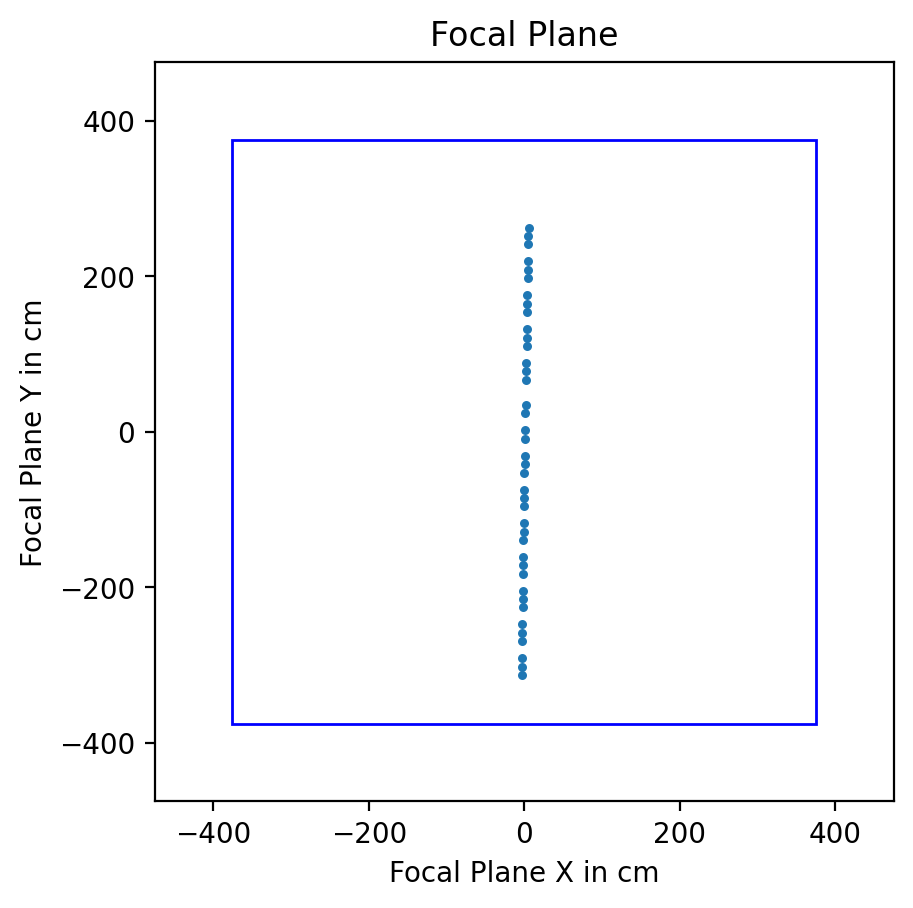

In [10]:
aperture_side = 750.8
plt.scatter(t['fp_x'], t['fp_y'], s=5)

aperture = Rectangle((-aperture_side/2, -aperture_side/2), aperture_side, aperture_side, edgecolor='b',facecolor='none')

plt.gca().add_patch(aperture)
plt.gca().set_aspect('equal')

plt.xlim(-aperture_side/2 - 100, aperture_side/2 + 100)
plt.ylim(-aperture_side/2 - 100, aperture_side/2 + 100)

plt.title('Focal Plane')
plt.xlabel('Focal Plane X in cm')
plt.ylabel('Focal Plane Y in cm')

#plt.colorbar(label='Milliseconds of Delay')

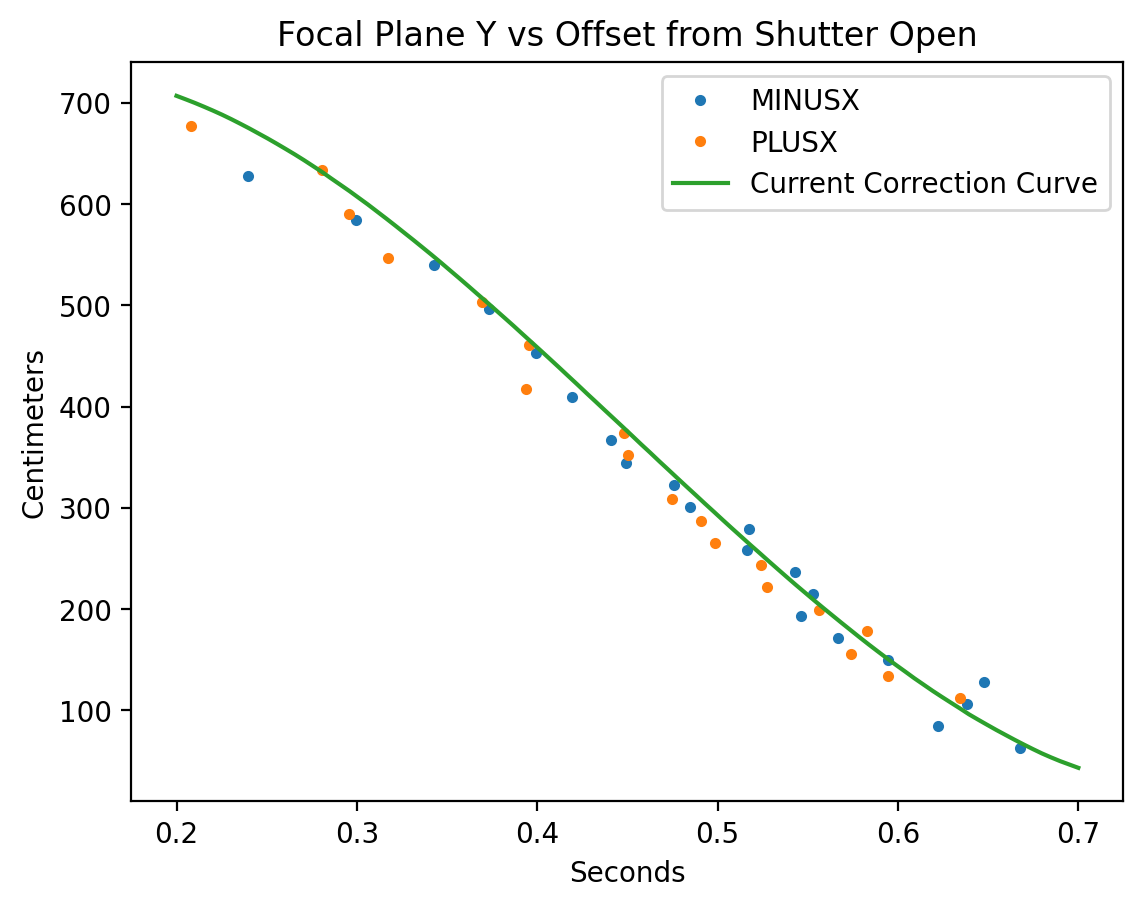

In [11]:
start_delay_minus = (t_minus['start_pos'].ra.arcsec - t_minus['sat_pos'].ra.arcsec) / 15.0
start_delay_plus = (t_plus['start_pos'].ra.arcsec - t_plus['sat_pos'].ra.arcsec) / 15.0
focal_plane_shift = aperture_side/2 * u.centimeter
time_positions = np.linspace(0.2, 0.7, 100)

plt.plot(start_delay_minus, t_minus['fp_y'] + focal_plane_shift, 'o', markersize=3.0, label ='MINUSX')
plt.plot(start_delay_plus, focal_plane_shift - t_plus['fp_y'] , 'o', markersize=3.0, label ='PLUSX')
plt.plot(time_positions, shutter_spline.__call__(time_positions), '-', label='Current Correction Curve')

plt.title('Focal Plane Y vs Offset from Shutter Open')
plt.xlabel('Seconds')
plt.ylabel('Centimeters')
plt.legend()


Text(0, 0.5, '$\\Delta DEC$ in arcsec')

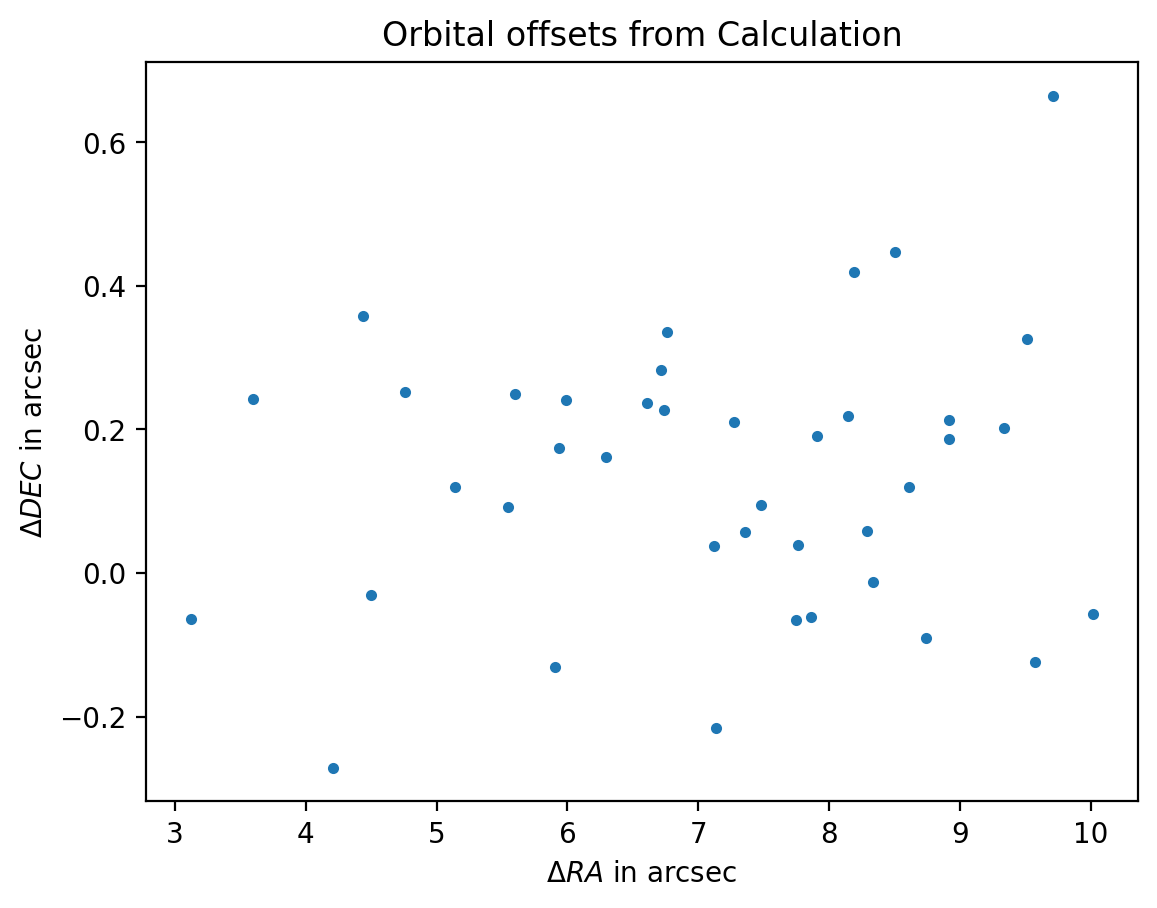

In [12]:
plt.plot(delta_ra, delta_dec, 'o', markersize=3.0)
plt.title('Orbital offsets from Calculation')
plt.xlabel(r'$\Delta RA$ in arcsec')
plt.ylabel(r'$\Delta DEC$ in arcsec')

Text(0.5, 0, '$\\Delta RA$ in arcsec')

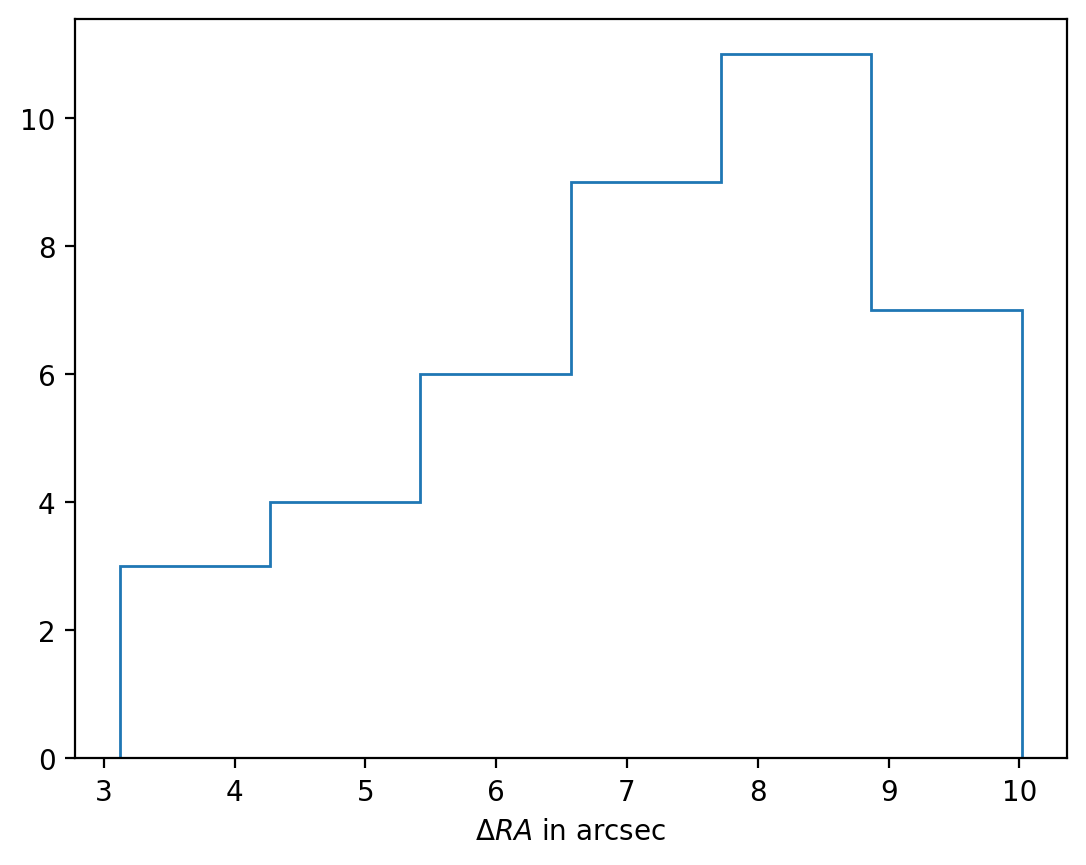

In [13]:
plt.hist(delta_ra, bins=6, histtype='step', label='All Observations')
plt.xlabel(r'$\Delta RA$ in arcsec')

7.931 Milliseconds


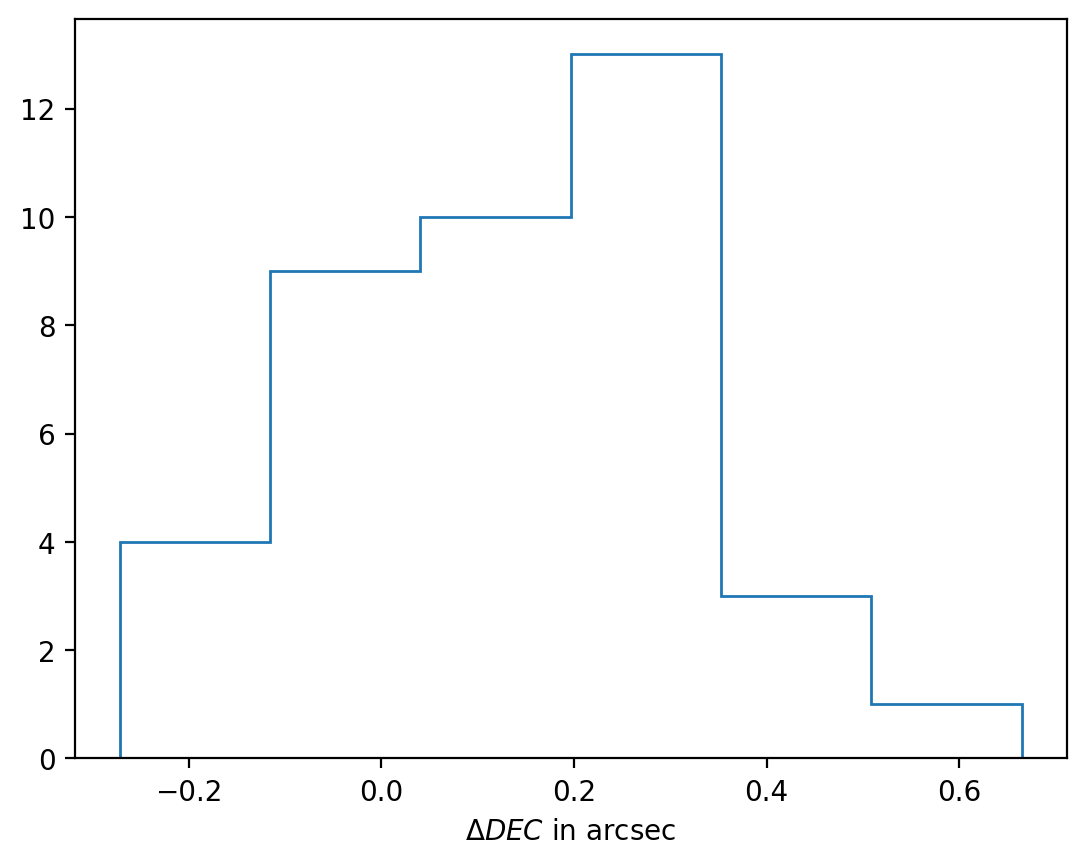

In [14]:
plt.hist(delta_dec, bins=6, histtype='step', label='All Observations')
plt.xlabel(r'$\Delta DEC$ in arcsec')
print(f'{adj_delta_dec.mean()/15.0 * 1000:4.3f} Milliseconds')

Text(0, 0.5, '$\\Delta DEC$ in arcsec')

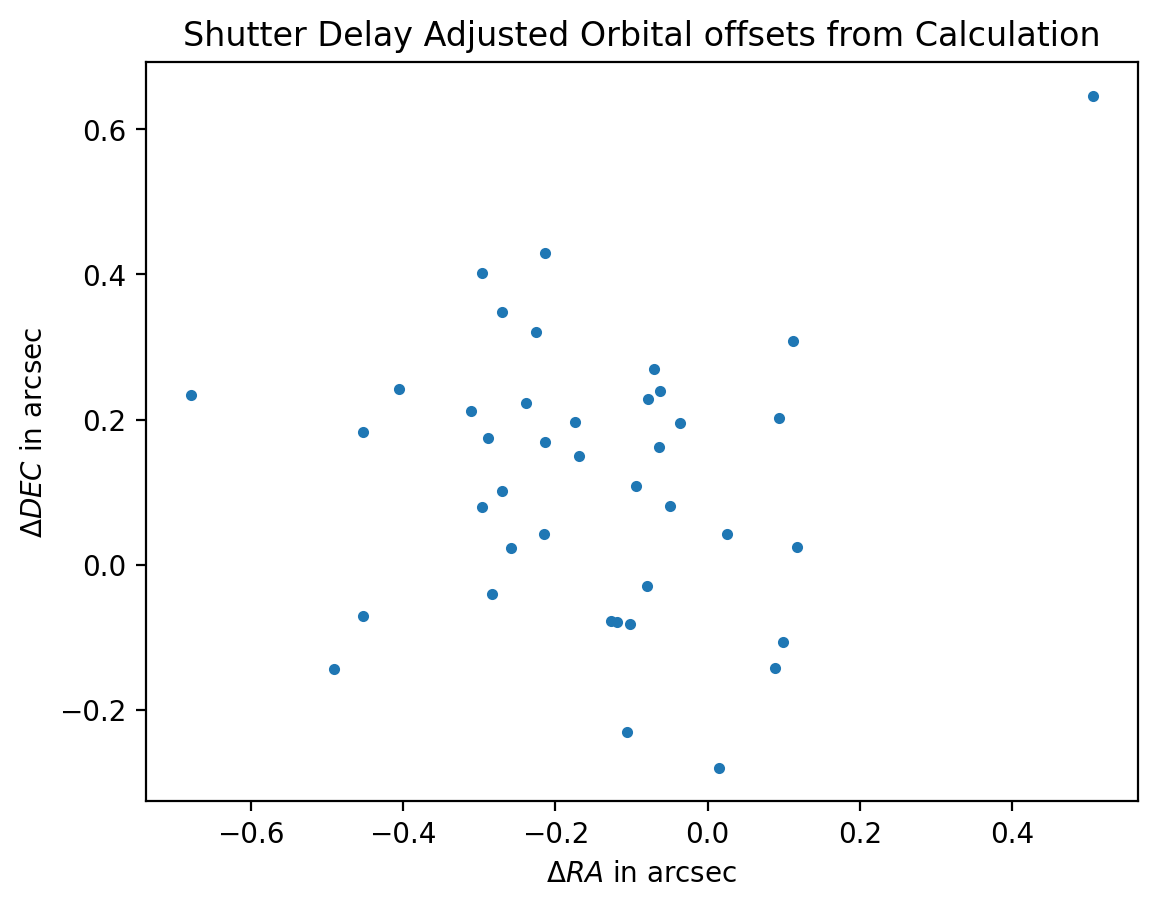

In [15]:
plt.plot(adj_delta_ra, adj_delta_dec, 'o', markersize=3.0)
plt.title('Shutter Delay Adjusted Orbital offsets from Calculation')
plt.xlabel(r'$\Delta RA$ in arcsec')
plt.ylabel(r'$\Delta DEC$ in arcsec')

Text(0.5, 0, '$\\Delta RA$ in arcsec')

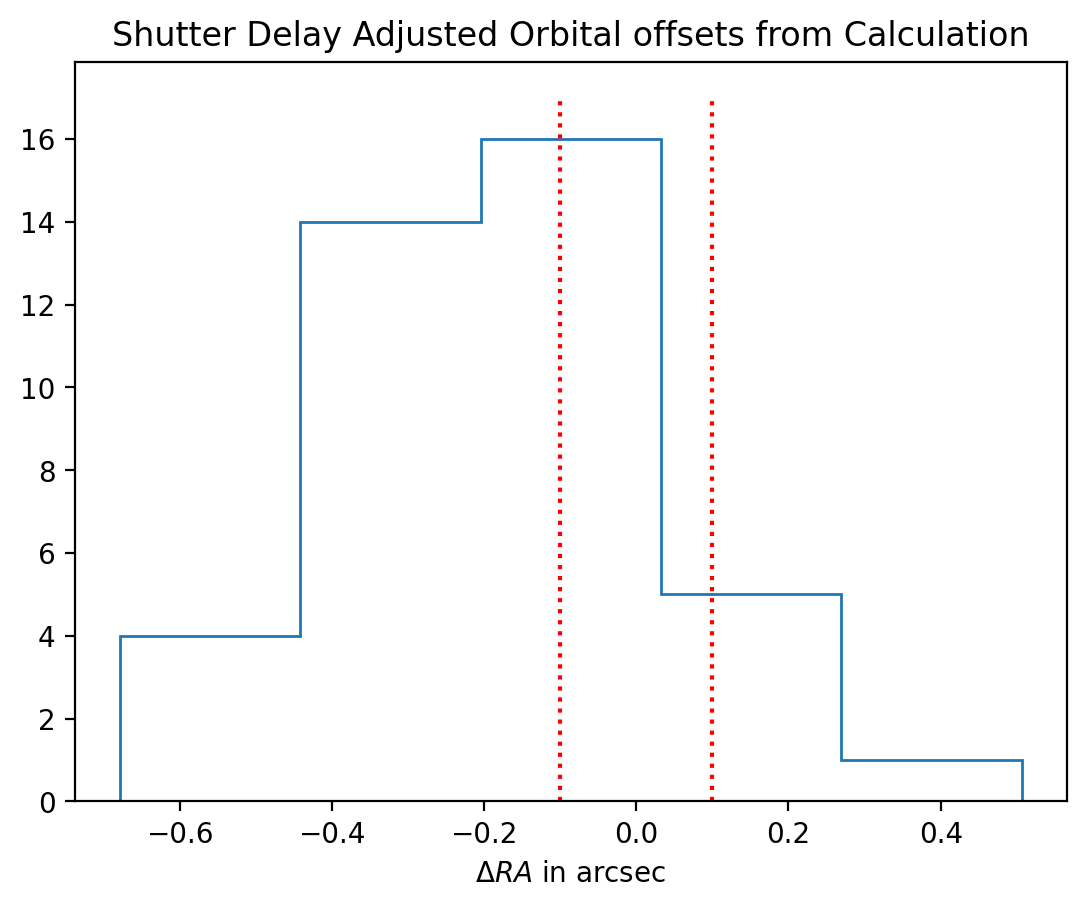

In [16]:
plt.hist(adj_delta_ra, bins=5, histtype='step', label='All Observations')

plt.title('Shutter Delay Adjusted Orbital offsets from Calculation')
plt.vlines(-0.1, 0, 17, linestyles='dotted', color='r')
plt.vlines(0.1, 0, 17, linestyles='dotted', color='r')
plt.xlabel(r'$\Delta RA$ in arcsec')

In [17]:
print(f'{adj_delta_ra.mean()/15.0 * 1000:4.3f} Milliseconds')
print(f'{adj_delta_ra.mean():4.3f} Arc Seconds')

-10.213 Milliseconds
-0.153 Arc Seconds


Text(0, 0.5, '$\\Delta RA$ in arcsec')

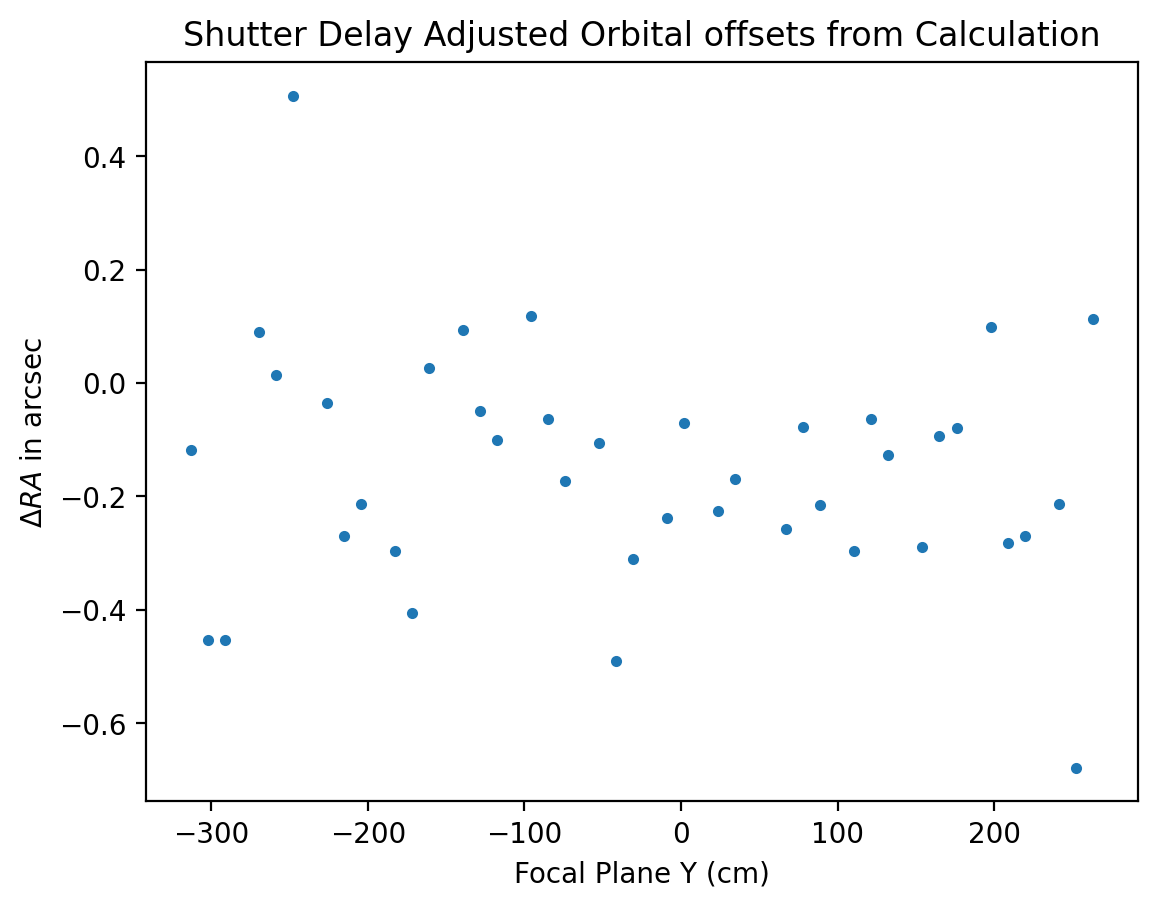

In [18]:
plt.plot(t['fp_y'], adj_delta_ra, 'o', markersize=3.0)
plt.title('Shutter Delay Adjusted Orbital offsets from Calculation')
plt.xlabel(r'Focal Plane Y (cm)')
plt.ylabel(r'$\Delta RA$ in arcsec')

np.float64(0.09392122546016353)

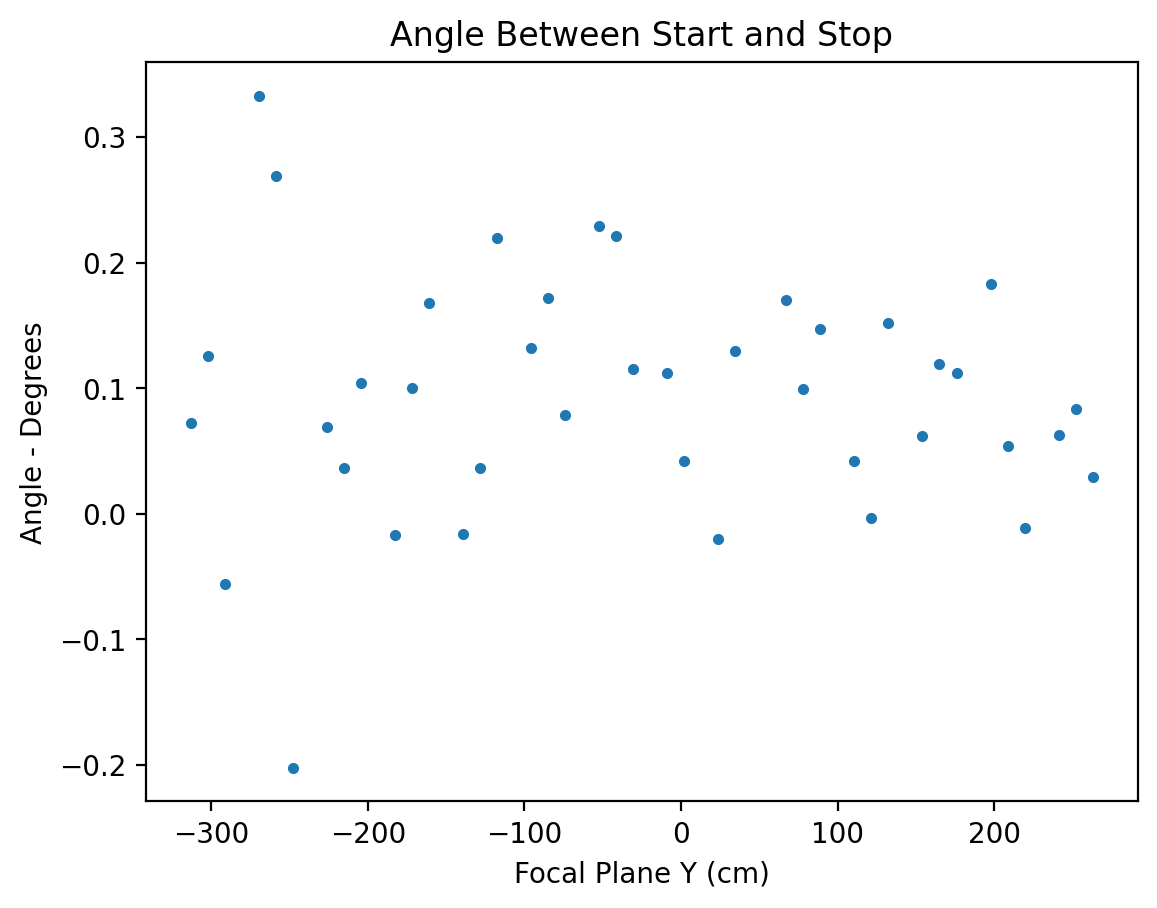

In [19]:
plt.plot(t['fp_y'], angle, 'o', markersize=3.0)
plt.title('Angle Between Start and Stop')
plt.xlabel(r'Focal Plane Y (cm)')
plt.ylabel(r'Angle - Degrees')
angle.mean()

### Work Area

In [20]:
# Use this Cell for a quick location calculation

tai_time = Time("2026-03-03T06:15:41.971", scale='tai') # Shutter Open - 439
#tai_time = Time("2026-03-03T06:15:56.390", scale='tai') # Shutter Open - 440

waas.create_interpolated_waas(tai_time, '.01s')
found_time, found_ra, found_dec = waas.calculate_waas_position(tai_time, shutter_offset= (0.9/2.0)*(7/8) * u.second)
#found_time, found_ra, found_dec = waas.calculate_waas_position(tai_time, shutter_offset = 0 * u.second)
print(tai_time.utc, found_time, found_ra, found_dec)

2026-03-03T06:15:04.971 2026-03-03 06:15:05.370000+00:00 131.5369505474492 4.835496120265168


In [21]:
# From here on, select an exposure and look at in detail.

seq_id = 439
#seq_id = 445
    
pvi = t.loc[seq_id]['pvi']
shutter_delay = t.loc[seq_id]['shutter_delay'] 
sat_pos = t.loc[seq_id]['sat_pos'] 

image = pvi.getImage().getArray()
detector = pvi.getDetector()
wcs = WCS(pvi.wcs.getFitsMetadata())
sky_wcs = pvi.wcs

(<matplotlib.image.AxesImage at 0x7f2072d50c20>,
 <astropy.visualization.mpl_normalize.ImageNormalize at 0x7f2072d50ad0>)

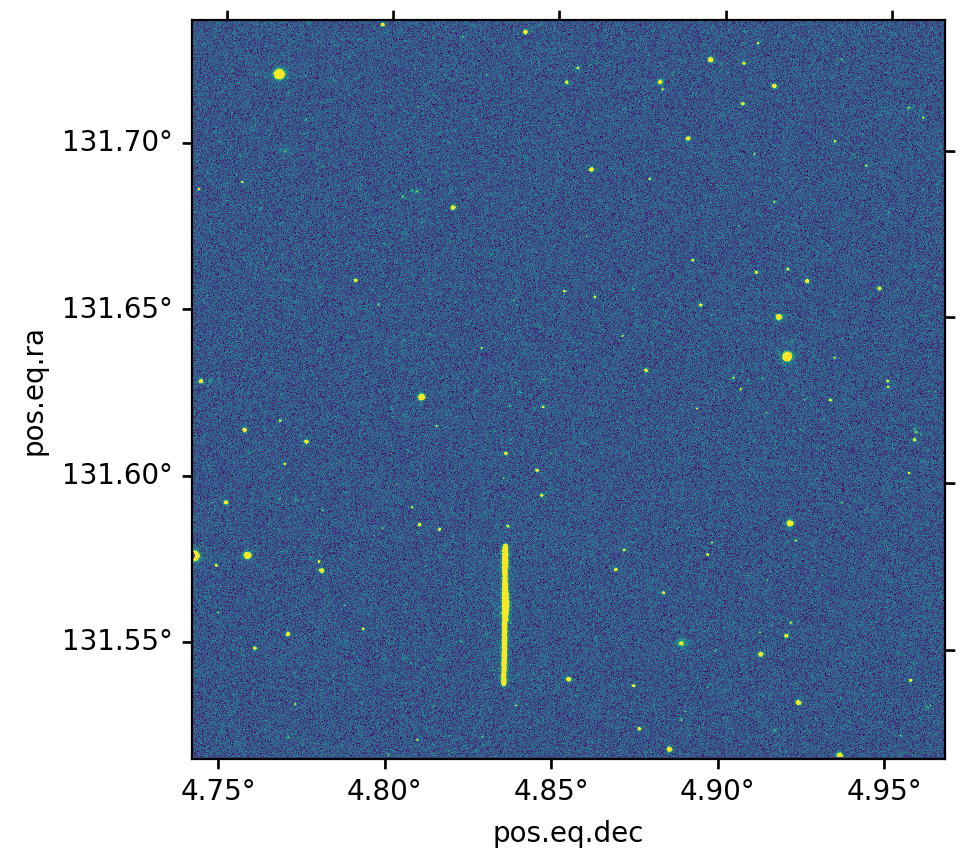

In [22]:
ax = plt.subplot(projection=wcs)
ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')

#plt.imshow(image, origin='lower', vmin=-70, vmax=150)
imshow_norm(image, origin='lower', interval=ZScaleInterval(n_samples=700), interpolation='none', stretch=LinearStretch())

False


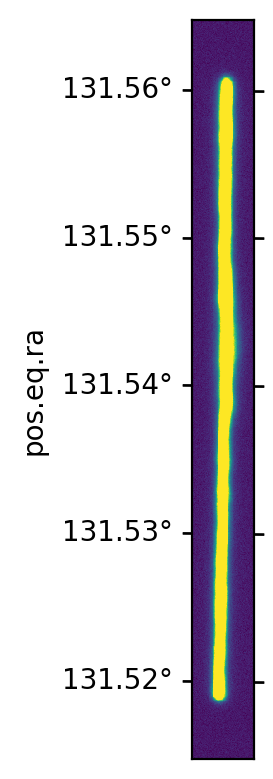

In [23]:
# Make cutout

ax = plt.subplot(projection=wcs)
ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')

ra_box = (15.0*u.arcsec * 12, 15*u.arcsec) 
ra_shift = 15*u.arcsec * 10 / 2.0 + shutter_delay * 15*u.arcsec/u.second
shifted_pos = sat_pos.spherical_offsets_by(ra_shift, 0*u.arcsec)

cut_out = Cutout2D(image, shifted_pos , ra_box, wcs=wcs, mode='partial')
imshow_norm(cut_out.data, origin='lower', interval=ZScaleInterval(n_samples=700), interpolation='none', stretch=LinearStretch())
print(np.isnan(cut_out.data).any())

array([32.27453483, 41.39745222])

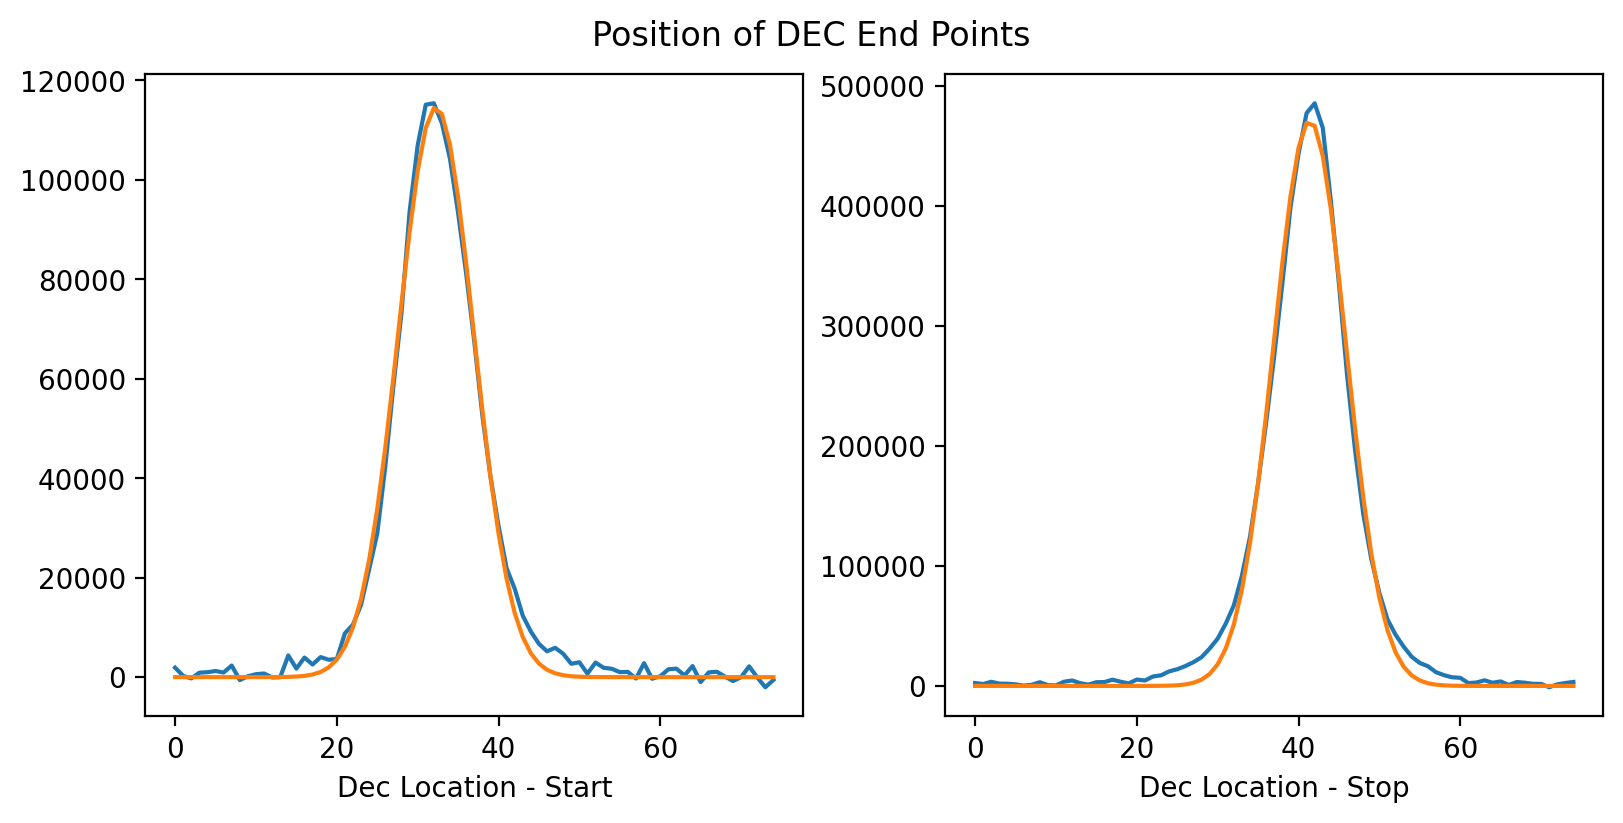

In [24]:
# Find Dec pixel coordinates

#ax = plt.subplot(projection=wcs, slices=('x', 0))
#ax.coords[0].set_major_formatter('d.dd')
#ax.coords[1].set_major_formatter('d.dd')

summed_dec_start = cut_out.data[:80].sum(axis=0)
summed_dec_stop = cut_out.data[-100:].sum(axis=0)

# Fit Gaussian
fitter = modeling.fitting.LevMarLSQFitter()
model_start = modeling.models.Gaussian1D(mean = summed_dec_start.shape[0]/2, amplitude = summed_dec_start.max())
model_stop = modeling.models.Gaussian1D(mean = summed_dec_stop.shape[0]/2, amplitude = summed_dec_stop.max())

x_values = np.arange(summed_dec_start.shape[0])
fitted_model_start = fitter(model_start, x_values, summed_dec_start)
mean_dec_start = fitted_model_start.mean

x_values = np.arange(summed_dec_stop.shape[0])
fitted_model_stop = fitter(model_stop, x_values, summed_dec_stop)
mean_dec_stop = fitted_model_stop.mean

# Plot Values

fig, axes = plt.subplot_mosaic('AB', constrained_layout=True, figsize=(8,4))
fig.suptitle(f'Position of DEC End Points')

# axes['A'] = fig.add_subplot(1,1,1, projection=wcs)
axes['A'].plot(x_values, summed_dec_start)
axes['A'].plot(x_values, fitted_model_start(x_values))

# axes['B'] = fig.add_subplot(1,2,1, projection=wcs)
axes['B'].plot(x_values, summed_dec_stop)
axes['B'].plot(x_values, fitted_model_stop(x_values))

axes['A'].set_xlabel('Dec Location - Start')
axes['B'].set_xlabel('Dec Location - Stop')

#plt.plot(x_values, summed_dec_start)
#plt.plot(x_values, fitted_model(x_values))
#plt.vlines(fitted_model.mean, 0, summed_dec_start.max()*1.10, color='green')

mean_dec = np.array([mean_dec_start.value, mean_dec_stop.value])
mean_dec

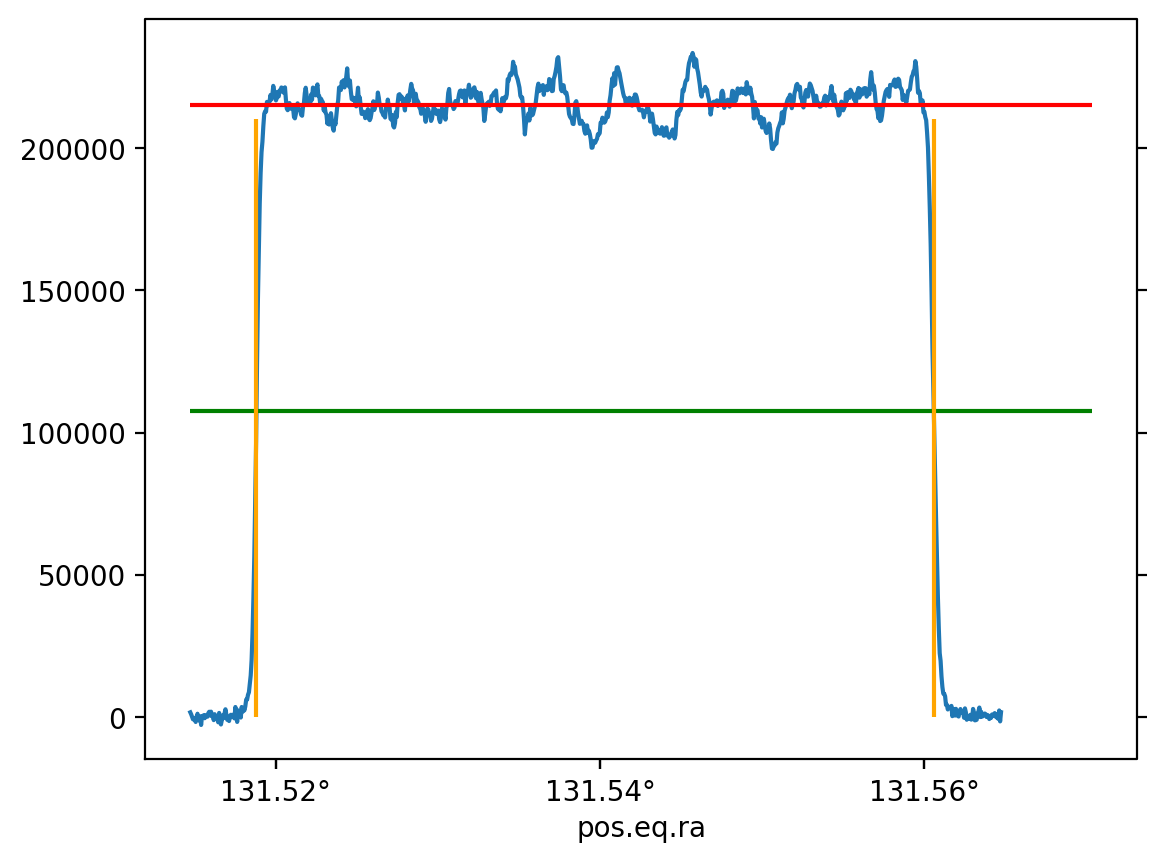

In [25]:
# Find Ra pixel coordinates

ax = plt.subplot(projection=wcs, slices=(0, 'x'))
ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')

summed = cut_out.data.sum(axis=1)
avg_sum = summed[summed>100000].mean()
half_sum = avg_sum * 0.5

x_values = np.arange(summed.shape[0])
spline = CubicSpline(x_values, summed)
half_points = spline.solve(half_sum, extrapolate=False)

plt.plot(summed)
plt.hlines(avg_sum, 0, 1000, color='red')
plt.hlines(half_sum, 0, 1000, color='green')
plt.vlines(half_points, 0, 210000, color='orange')

# half_points.size
#t['seq_id'][5], adj_delta_ra[5], adj_delta_dec[5]

In [26]:
# Find derivatives

derivatives = spline.derivative(1).__call__(x_values)
max_deriv = derivatives.argmax()
min_deriv = derivatives.argmin()

#plt.plot(derivatives)
#max_deriv, min_deriv

In [27]:
# Convert results to to RA/DEC

half_pixelcoord = np.column_stack([mean_dec, half_points])
deriv_pixelcoord = np.column_stack([mean_dec, [max_deriv, min_deriv]])

coordinates_original = [cut_out.to_original_position(half_pixelcoord[i]) for i in range(2)]
half_skycoord = [pixel_to_skycoord(half_pixelcoord[i, 0], half_pixelcoord[i, 1], wcs=cut_out.wcs) for i in range(2)]

#display(half_pixelcoord)
#display(coordinates_original)
#display(half_skycoord)

print('# Expected Start Positions')
print(f'circle {t.loc[seq_id]['sat_pos'].ra.deg:5.8f}, {t.loc[seq_id]['sat_pos'].dec.deg:5.8f}, 2.0" # color=green')
print(f'circle {t.loc[seq_id]['adj_pos'].ra.deg:5.8f}, {t.loc[seq_id]['adj_pos'].dec.deg:5.8f}, 2.0" # color=green')
print()

print('# Fitted Track Ends')
print(f'circle {half_skycoord[0].ra.deg:5.8f}, {half_skycoord[0].dec.deg:5.8f}, 2.0" # color=yellow')
print(f'circle {half_skycoord[1].ra.deg:5.8f}, {half_skycoord[1].dec.deg:5.8f}, 2.0" # color=yellow')
print()

# This uses sky_wcs
# half_skywcs = [sky_wcs.pixelToSkyArray(coordinates_original[i][0], coordinates_original[i][1], degrees=True) for i in range(2)]
# print(f'circle {half_skywcs[0][0][0]:5.5f}, {half_skywcs[0][1][0]:5.5f}, 2.0" # color=yellow')
# print(f'circle {half_skywcs[1][0][0]:5.5f}, {half_skywcs[1][1][0]:5.5f}, 2.0" # color=yellow')

# Expected Start Positions
circle 131.53530529, 4.83549276, 2.0" # color=green
circle 131.53812061, 4.83549851, 2.0" # color=green

# Fitted Track Ends
circle 131.53808773, 4.83547673, 2.0" # color=yellow
circle 131.57986026, 4.83552781, 2.0" # color=yellow



### MINUIT Fit

In [28]:
# Minuit PDF for fitting
def pdf(modified_julian_dates, time_offset = 0):

    # Turn the MJD float back into a TAI Time object (minuit must pass a float)
    # Note something subtle: When we do this we lose precision so the times are slightly different. 
    # So, we will actually use the values in the Astropy Table instead in the call to the position calc.
    # This makes a difference in the fit errors at the .02 millisecond level.

    tai_vector = Time(modified_julian_dates, format='mjd', scale='tai')
    time_offset = time_offset * u.second
    
    sat_ra = np.zeros(len(tai_vector))
    
    for i,row in enumerate(t):
        
        # Find interpolated time and sky position
        waas.create_interpolated_waas(row['tai_start_time'], '.01s')

        _, sat_ra[i], _ = waas.calculate_waas_position(row['tai_start_time'], shutter_offset= row['shutter_delay'],
                                                       time_offset=time_offset)

    return sat_ra

# Fitting visualization function
def viz(args):
    plt.hist((measured_ra - pdf(times, 0))*3600, bins=6, histtype='step', label='TAI Time')
    plt.hist((measured_ra - pdf(times, *args))*3600, bins=6, histtype='step', label='Fitted Offset')

    plt.legend(loc="upper right")
    plt.xlabel(r'$\Delta RA$ in arcsec')


# Fit the time offset
times = t['tai_start_time'].mjd
measured_ra = t['start_pos'].ra.deg
error_ra = 0.2 / 3600

least_squares = LeastSquares(times, measured_ra, error_ra, pdf) 
least_squares.visualize = viz

m = Minuit(least_squares, time_offset= 0.0)  # starting values for offset

m.migrad()  # finds minimum of least_squares function
#m.hesse()  # accurately computes uncertainties

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 42.2 (χ²/ndof = 1.1)       │              Nfcn = 17               │
│ EDM = 3.04e-09 (Goal: 0.0002)    │           time = 66.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name        │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ time_offset │  -0.0102  │  0.0021   │            │            │         │         │       │
└───┴─────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────────────┬─────────────┐
│             │ time_offset │
├─────────────┼─────────────┤
│ time_offset │    4.37e-06 │
└─────────────┴─────────────┘

In [29]:
print(f'{m.values[0]*1000:5.2f} +- {m.errors[0]*1000:4.2f} milliseconds')
print(f'{m.values[0]*1000*.075:5.2f} +- {m.errors[0]*1000*.075:4.2f} pixels')
print(f'FCN: {m.fcn(m.values):4.4f}')
print()
print(f'{m.values[0]/m.errors[0]:2.2} sigma from zero')

-10.18 +- 2.09 milliseconds
-0.76 +- 0.16 pixels
FCN: 42.2037

-4.9 sigma from zero


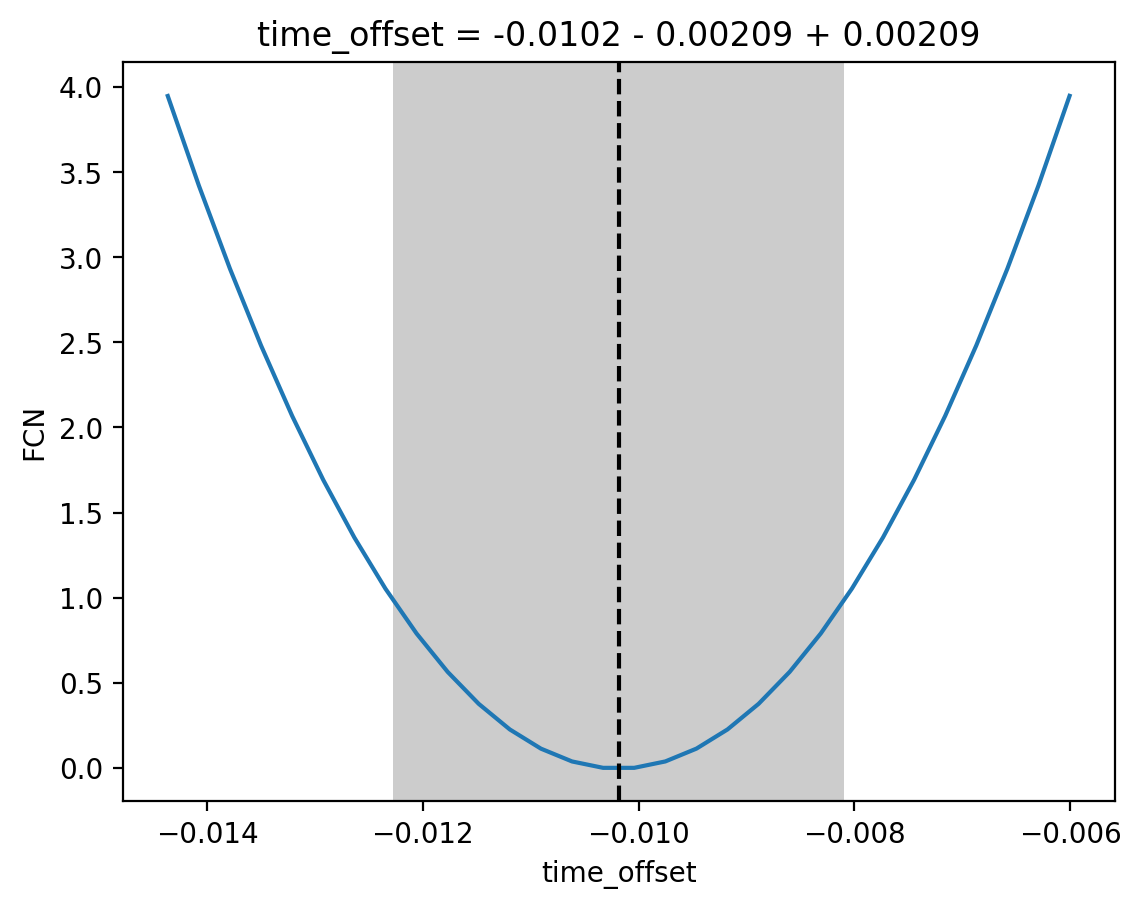

In [30]:
m.draw_mnprofile("time_offset");

Text(0.5, 0, '$\\Delta RA$ in arcsec')

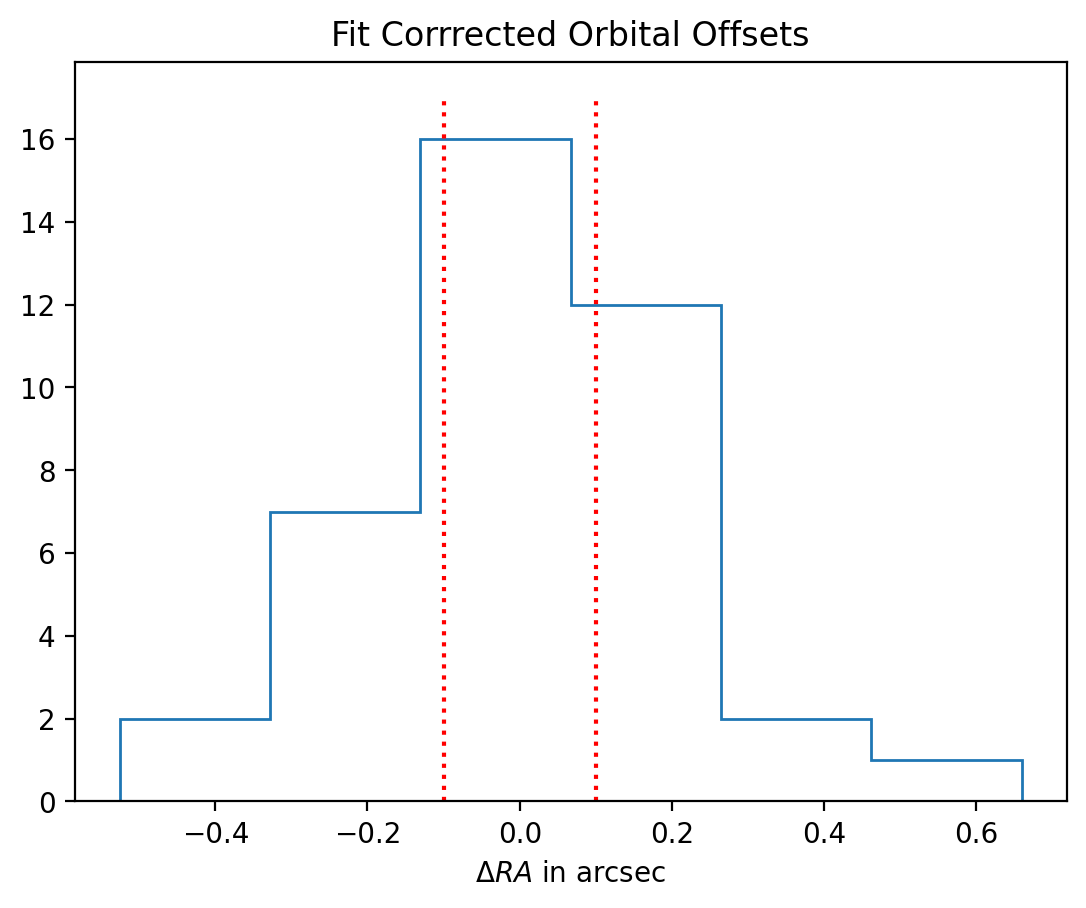

In [31]:
plt.hist((measured_ra - pdf(times, time_offset = m.values[0]))*3600, histtype='step', bins=6)

plt.title('Fit Corrrected Orbital Offsets')
plt.vlines(-0.1, 0, 17, linestyles='dotted', color='r')
plt.vlines(0.1, 0, 17, linestyles='dotted', color='r')
plt.xlabel(r'$\Delta RA$ in arcsec')

Pulls mean = -0.000016 std = 1.03


Text(0.5, 0, 'Pull Value')

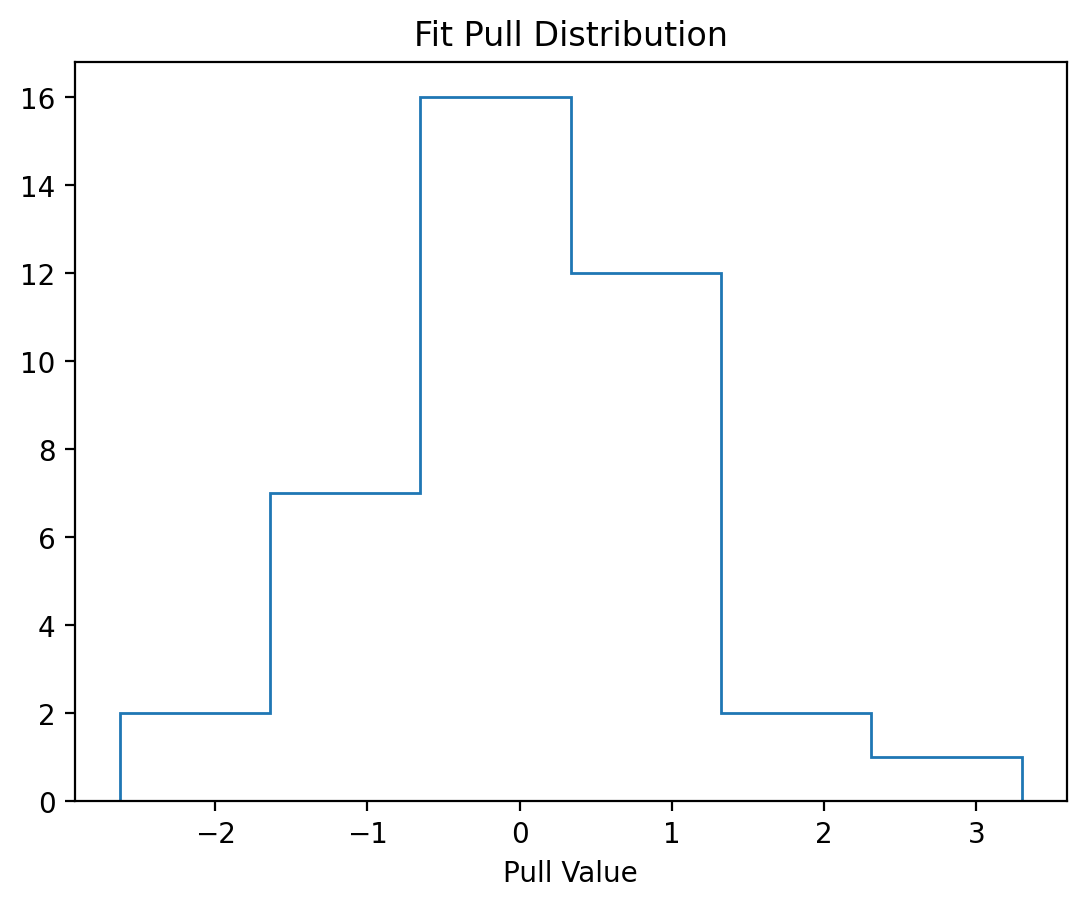

In [32]:
pulls = least_squares.pulls(m.values)
print(f'Pulls mean = {pulls.mean():4.6f} std = {pulls.std():4.2f}')

plt.hist(least_squares.pulls(m.values),histtype='step', bins=6)

plt.title('Fit Pull Distribution')
plt.xlabel(r'Pull Value')


np.float64(30.58652507180044)

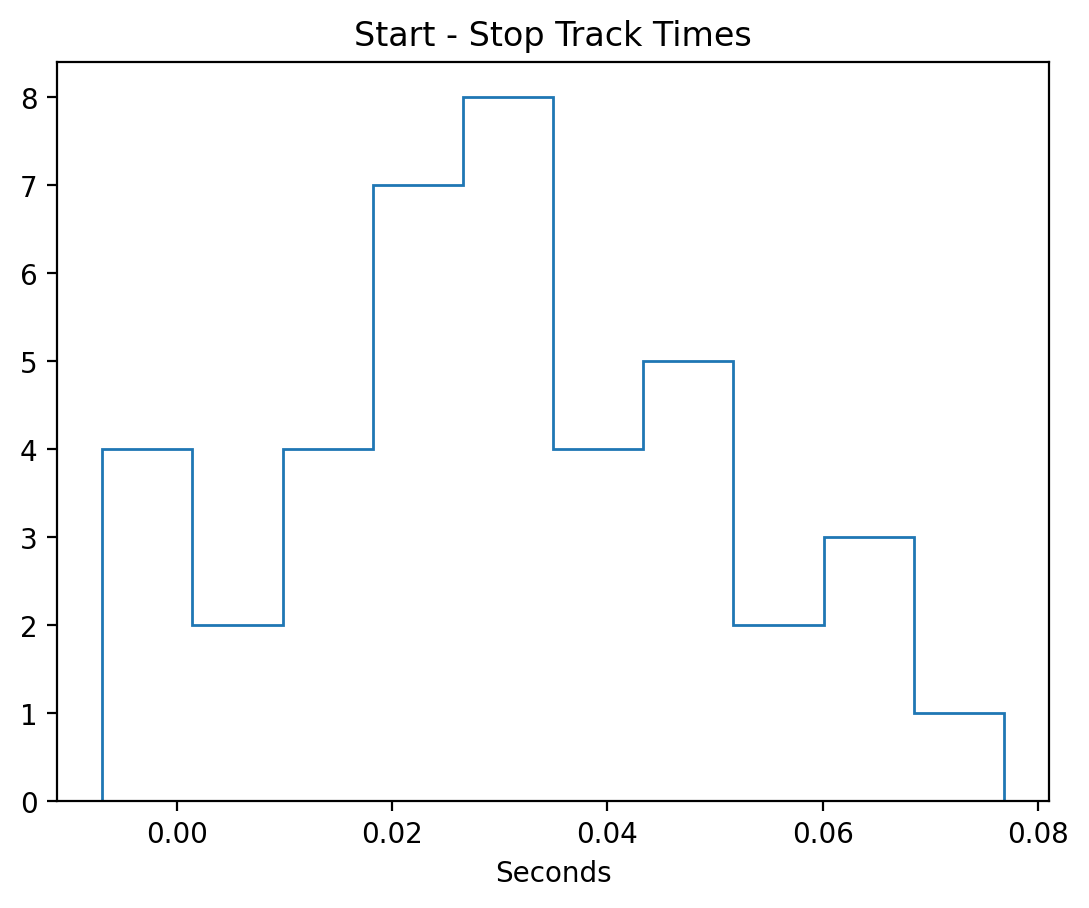

In [33]:
exposure_length = (t['stop_pos'].ra.arcsec - t['start_pos'].ra.arcsec)/15.0 - 10.0
plt.hist(exposure_length, histtype='step', bins=10)

plt.title('Start - Stop Track Times')
plt.xlabel('Seconds')

(exposure_length.mean()) * 1000.0